In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 5: Baseline Cell Detection on a Single Timepoint

**Objective:** Build a simple baseline method to detect likely cell centers in one 3D microscopy frame and compare those detections to the ground-truth centroids.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- select one labeled sample and one timepoint for a detection experiment
- extract the ground-truth cell centroids for that timepoint
- inspect the 3D microscopy frame as a stack of z-slices
- build a simple baseline detector for likely cell centers
- compare predicted points against the ground-truth labels visually
- understand why detection is only one part of the full competition pipeline

# 🧠 Background Theory

The full competition requires reconstructing a tracking graph across time. But before I can link cells across time, I first need to detect cells within a single 3D frame.

In this chapter, I will treat one timepoint as a **3D detection problem**:

- input: one 3D microscopy volume at time `t`
- output: a set of predicted cell center coordinates `(z, y, x)`

The ground-truth labels are sparse, so they do not represent every visible cell in the image. That means this notebook is mainly for **building intuition and a baseline workflow**, not for measuring final competition performance.

# 🗺️ Chapter Roadmap

This notebook will proceed in six stages:

1. **Load one sample and inspect its labels**
2. **Choose one timepoint with several labeled cells**
3. **Extract the 3D frame and the ground-truth centroids**
4. **Visualize the labeled cells in the image stack**
5. **Build a simple baseline detector**
6. **Compare predicted detections to ground-truth labels**

# 📚 New Vocabulary

## Detection
The task of identifying where cells are located in an image.

## Centroid
The center point of a labeled cell, represented here by integer `(z, y, x)` coordinates.

## 3D Frame
One timepoint of the microscopy movie, with shape `(Z, Y, X)`.

## Baseline Model / Baseline Detector
A simple first method used to establish a starting point before trying more advanced approaches.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.4 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

print("zarr version:", zarr.__version__)

zarr version: 3.3.0


In [4]:
sample_id = "44b6_12dfb391"

# Step 1 — Load One Training Sample

To keep the notebook focused, I will continue using the sample `44b6_12dfb391`, which I already explored in earlier chapters.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"

zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

print("Using sample:", sample_id)
print("Zarr exists:", zarr_path.exists())
print("GEFF exists:", geff_path.exists())

Using sample: 44b6_12dfb391
Zarr exists: True
GEFF exists: True


# Step 2 — Load the 4D Image Volume and Ground-Truth Node Coordinates

I need two things:

- the image volume from the `.zarr` file
- the labeled node coordinates from the `.geff` file

In [6]:
# Load image
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

# Load graph
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("Total labeled nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
Total labeled nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 3 — Choose a Timepoint with Several Ground-Truth Labels

For a first detection experiment, I want a timepoint with multiple labeled cells so that I can compare my predictions to several known centroids.

In [7]:
nodes_per_time = nodes_df["t"].value_counts().sort_index()

print(nodes_per_time.head(20))
print("\nBest timepoint:")
best_t = nodes_per_time.idxmax()
print("best_t =", best_t, "| labels =", nodes_per_time.max())

t
0     10
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     11
9     11
10    10
11    10
12    10
13    10
14    10
15     9
16     9
17     9
18     9
19     9
Name: count, dtype: int64

Best timepoint:
best_t = 8 | labels = 11


# Step 4 — Extract the 3D Frame and Its Ground-Truth Centroids

Now I will isolate one timepoint from the full 4D movie.

This gives me:

- one **3D image frame** with shape `(Z, Y, X)`
- one table of **ground-truth centroids** for that same timepoint

This is the basic detection problem for the rest of the notebook.

In [8]:
t = best_t

frame_3d = image[t]   # shape: (Z, Y, X)
gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")

print("Selected timepoint:", t)
print("3D frame shape:", frame_3d.shape)
print("Ground-truth nodes at this timepoint:", len(gt_nodes_t))

gt_nodes_t

Selected timepoint: 8
3D frame shape: (64, 256, 256)
Ground-truth nodes at this timepoint: 11


,node_id,t,z,y,x
82,114000000041,8,10,237,65
81,114000000040,8,15,184,60
87,114000000080,8,17,248,101
90,114000000084,8,18,2,116
89,114000000082,8,22,199,63
84,114000000043,8,25,208,115
83,114000000042,8,27,156,0
88,114000000081,8,28,122,100
80,114000000037,8,37,50,192
86,114000000063,8,40,198,98


# Step 5 — Visualize the Ground-Truth Cells Across the Z-Stack

Before building a detector, I want to inspect the 3D frame visually.

I will look at a set of z-slices and overlay any ground-truth centroids that lie exactly on those slices.

This helps me understand:

- how the labeled cells are distributed across depth
- how bright or faint they appear
- whether they look like isolated blobs or crowded structures

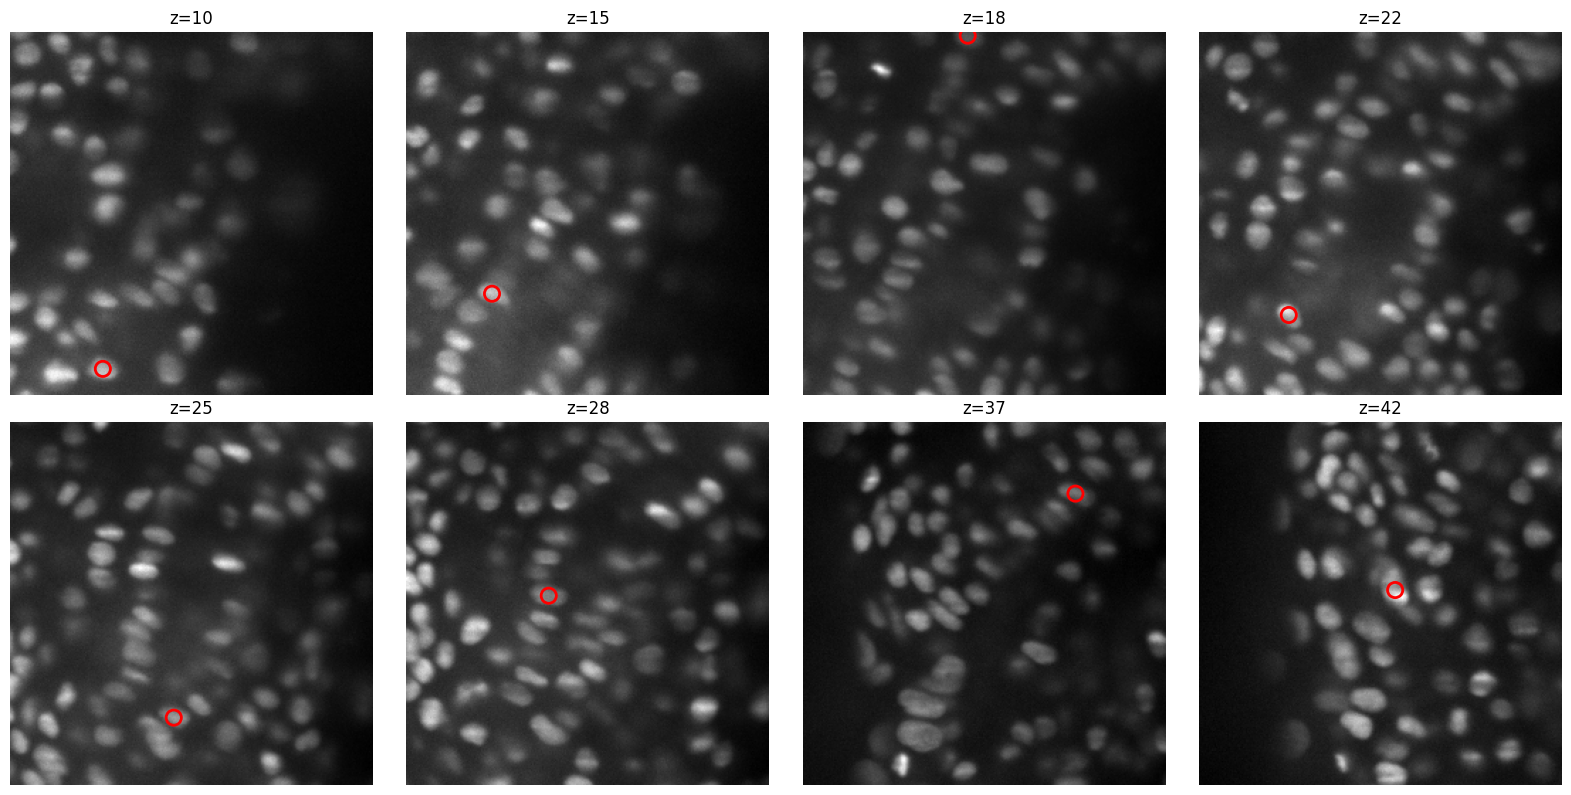

In [9]:
z_slices_to_plot = [10, 15, 18, 22, 25, 28, 37, 42]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, z_slices_to_plot):
    slice_2d = frame_3d[z]
    slice_nodes = gt_nodes_t[gt_nodes_t["z"] == z]

    ax.imshow(slice_2d, cmap="gray")
    ax.scatter(
        slice_nodes["x"],
        slice_nodes["y"],
        s=120,
        facecolors="none",
        edgecolors="red",
        linewidths=2
    )
    ax.set_title(f"z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Step 6 — Prepare a Simple 3D Local-Maxima Detector

For the first baseline detector, I will use a local-maxima approach:

1. smooth the 3D image
2. find bright peaks
3. treat those peaks as predicted cell centers

This will not solve the competition, but it will give me a first end-to-end detection workflow.

In [10]:
from skimage.feature import peak_local_max
from scipy.ndimage import gaussian_filter

print("Imports successful.")

Imports successful.


In [11]:
# Smooth the 3D frame to reduce noise
smoothed_frame = gaussian_filter(frame_3d, sigma=1)

# Find bright local peaks in 3D
predicted_points = peak_local_max(
    smoothed_frame,
    min_distance=5,
    threshold_abs=np.percentile(smoothed_frame, 99.5),
    exclude_border=False
)

print("Number of predicted points:", len(predicted_points))
print("First 10 predicted points:")
print(predicted_points[:10])

Number of predicted points: 144
First 10 predicted points:
[[ 57  31 255]
 [ 52  35 163]
 [ 40 239 101]
 [ 37 238  70]
 [ 55 164 255]
 [ 54  70 210]
 [ 55  70 237]
 [ 48 197 255]
 [ 55 122 240]
 [ 42 122 141]]


# Step 7 — Convert the Predicted Peaks into a Table

The local-maxima detector returns an array of `(z, y, x)` coordinates.

I will convert those predictions into a DataFrame so that they can be compared more easily to the ground-truth centroids.

In [12]:
pred_df = pd.DataFrame(predicted_points, columns=["z", "y", "x"])
pred_df.head(10)

,z,y,x
0,57,31,255
1,52,35,163
2,40,239,101
3,37,238,70
4,55,164,255
5,54,70,210
6,55,70,237
7,48,197,255
8,55,122,240
9,42,122,141


In [13]:
gt_z_values = sorted(gt_nodes_t["z"].unique())
pred_on_gt_slices = pred_df[pred_df["z"].isin(gt_z_values)].copy()

print("Ground-truth z slices:", gt_z_values)
print("Predictions on those z slices:", len(pred_on_gt_slices))

pred_on_gt_slices.head(20)

Ground-truth z slices: [np.int64(10), np.int64(15), np.int64(17), np.int64(18), np.int64(22), np.int64(25), np.int64(27), np.int64(28), np.int64(37), np.int64(40), np.int64(42)]
Predictions on those z slices: 34


,z,y,x
2,40,239,101
3,37,238,70
9,42,122,141
10,27,61,176
13,28,111,0
19,25,102,92
21,18,26,54
22,40,53,97
43,40,33,238
44,25,99,150


# Step 8 — Compare Predicted Peaks to Ground-Truth Labels on the Same Slices

Now I want to compare the baseline detector to the labels visually.

For each selected z-slice, I will plot:

- **ground-truth centroids** in red circles
- **predicted local maxima** in cyan X markers

This will help me understand whether the detector is at least placing peaks near the labeled cells, even if it produces too many false positives.

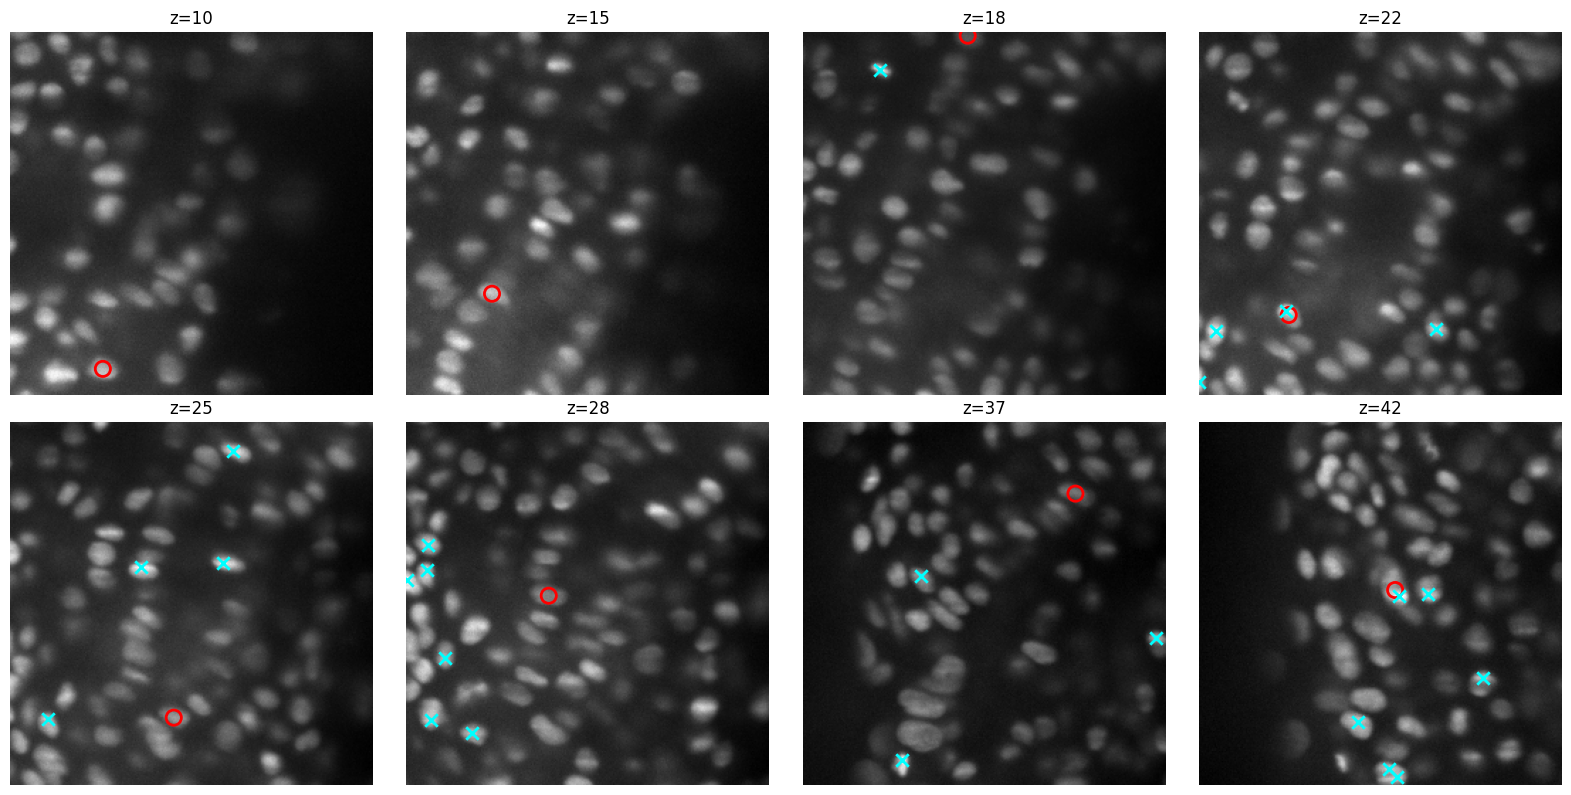

In [14]:
z_slices_to_compare = [10, 15, 18, 22, 25, 28, 37, 42]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, z_slices_to_compare):
    slice_2d = frame_3d[z]

    gt_slice = gt_nodes_t[gt_nodes_t["z"] == z]
    pred_slice = pred_df[pred_df["z"] == z]

    ax.imshow(slice_2d, cmap="gray")

    # Ground truth = red circles
    ax.scatter(
        gt_slice["x"],
        gt_slice["y"],
        s=120,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        label="Ground truth"
    )

    # Predictions = cyan X
    ax.scatter(
        pred_slice["x"],
        pred_slice["y"],
        s=80,
        c="cyan",
        marker="x",
        linewidths=2,
        label="Predicted peak"
    )

    ax.set_title(f"z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Step 9 — Tighten the Baseline Detector

The first local-maxima detector produced too many peaks.

To make the detector stricter, I will:

- increase the minimum distance between peaks
- raise the intensity threshold

This should reduce false positives, although it may also miss some true cells.

In [15]:
# Stricter detector settings
predicted_points_strict = peak_local_max(
    smoothed_frame,
    min_distance=8,
    threshold_abs=np.percentile(smoothed_frame, 99.8),
    exclude_border=False
)

pred_strict_df = pd.DataFrame(predicted_points_strict, columns=["z", "y", "x"])

print("Number of strict predicted points:", len(pred_strict_df))
pred_strict_df.head(10)

Number of strict predicted points: 83


,z,y,x
0,57,31,255
1,52,35,163
2,40,239,101
3,37,238,70
4,55,164,255
5,54,70,210
6,55,70,237
7,48,197,255
8,55,122,240
9,42,122,141


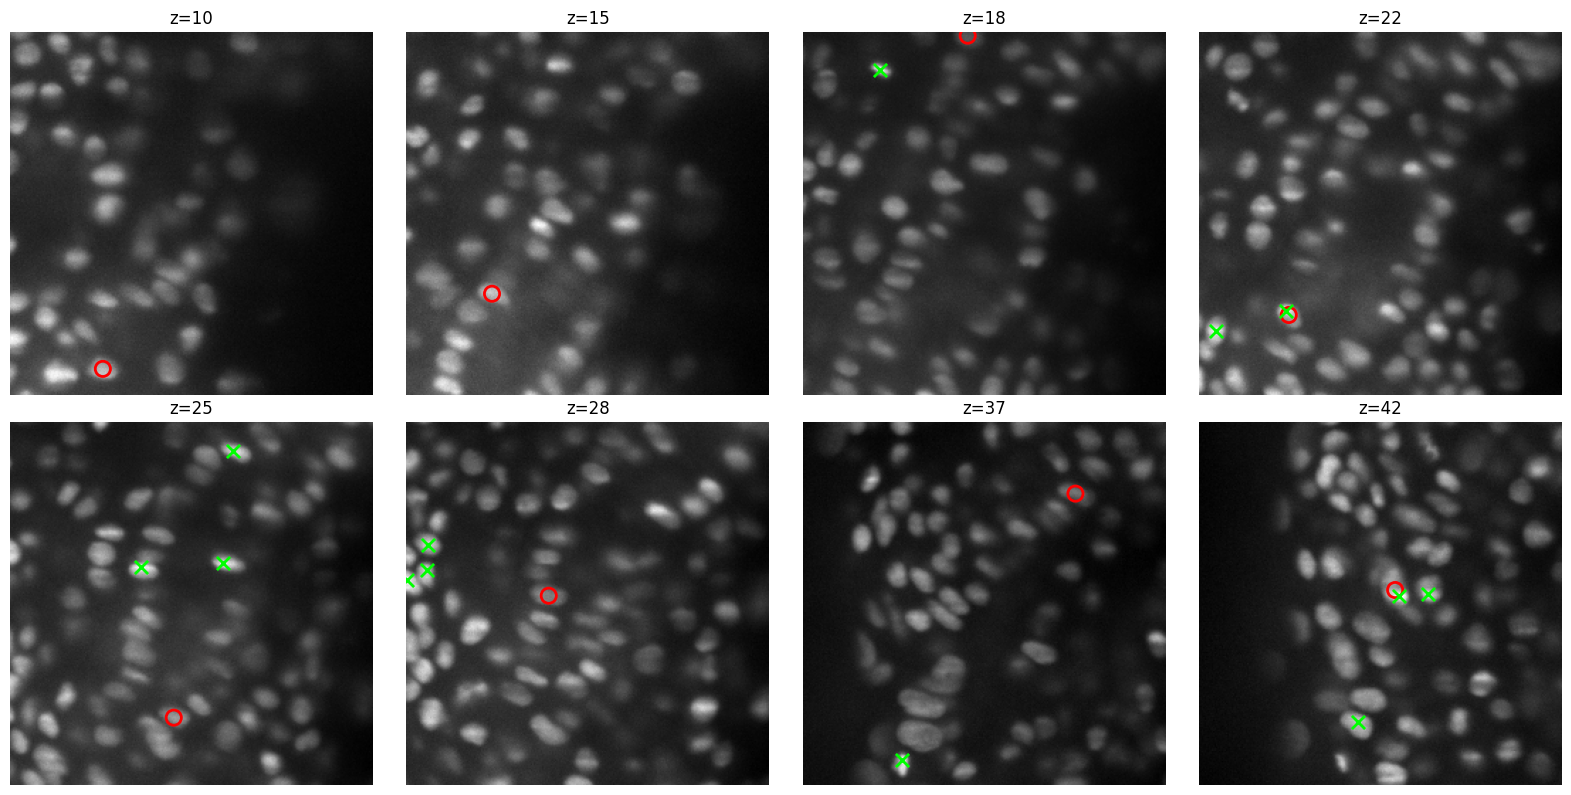

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, z_slices_to_compare):
    slice_2d = frame_3d[z]

    gt_slice = gt_nodes_t[gt_nodes_t["z"] == z]
    pred_slice = pred_strict_df[pred_strict_df["z"] == z]

    ax.imshow(slice_2d, cmap="gray")

    # Ground truth = red circles
    ax.scatter(
        gt_slice["x"],
        gt_slice["y"],
        s=120,
        facecolors="none",
        edgecolors="red",
        linewidths=2
    )

    # Stricter predictions = lime X
    ax.scatter(
        pred_slice["x"],
        pred_slice["y"],
        s=90,
        c="lime",
        marker="x",
        linewidths=2
    )

    ax.set_title(f"z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 📊 Results

The first baseline detector used 3D local maxima on a smoothed microscopy frame.

## Baseline 1
Settings:

- `sigma = 1`
- `min_distance = 5`
- threshold = 99.5th percentile

Result:

- **144 predicted points**

## Baseline 2: stricter detector
Settings:

- `sigma = 1`
- `min_distance = 8`
- threshold = 99.8th percentile

Result:

- **83 predicted points**

The stricter detector reduced false positives, but it still produced many more candidate points than the 11 sparse ground-truth labels.

# 🔍 Analysis

The local-maxima detector is useful as a first baseline because it finds bright, cell-like peaks in the 3D volume.

However, the detector has several limitations:

- it detects many unlabeled bright cells
- it can miss labeled cells if they are not strong local maxima
- it is sensitive to parameter choices
- it does not understand tracking or cell divisions
- it does not account for the sparse nature of the ground truth

This shows that cell detection is only the first part of the competition.

# 🚀 Next Steps

## Chapter 6 — Tuning and Evaluating the Baseline Detector

In the next notebook, I want to:

- compare different detector settings
- calculate distances from predicted points to ground-truth centroids
- estimate true positives, false positives, and missed labels
- build a simple detection scoring function
- choose better parameters before moving to tracking